# Data exploration

In this notebook we explore the data that will be used to train the AI Model

In [1]:
import geopandas as gpd
import leafmap
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr
from spai.storage.LocalStorage import LocalStorage
from rasterio.plot import show
import rasterio as rio
from glob import glob
import pandas as pd
import os

In [2]:
path = '../data'

We select an area in Seadur, Galicia, Spain where fires occured in August 2025.

In [3]:

aoi = gpd.read_file(f"{path}/aois/seadur.geojson")
m = leafmap.Map(center=[aoi.geometry.centroid.y.mean(), aoi.geometry.centroid.x.mean()], zoom=10)
m.add_gdf(aoi, layer_name="AOI")
m

Map(center=[np.float64(42.45322110840186), np.float64(-6.956751683866316)], controls=(ZoomControl(options=['po…

In [4]:
dates = [
    '2025-08-01',
    '2025-08-31',
]

We use the VIIRS dataset to get the hotspots in Spain for 2025.

In [6]:
hotspots = gpd.read_file(f"{path}/NW_Spain_2025_VIIRS_hotspots.geojson")

In [7]:
hotspots

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,41.91669,-8.37844,337.60,0.48,0.48,2025-01-01,1252,N,VIIRS,n,2,280.02,7.78,D,0,POINT (-8.37844 41.91669)
1,40.98245,-7.97106,346.39,0.36,0.58,2025-01-02,1413,N,VIIRS,n,2,268.12,5.42,D,0,POINT (-7.97106 40.98245)
2,43.55367,-5.85990,299.82,0.50,0.41,2025-01-13,0243,N,VIIRS,n,2,277.85,1.07,N,2,POINT (-5.8599 43.55367)
3,42.31948,-8.37830,334.20,0.77,0.77,2025-01-14,1208,N,VIIRS,n,2,280.88,6.95,D,0,POINT (-8.3783 42.31948)
4,42.32249,-8.38035,332.98,0.77,0.77,2025-01-14,1208,N,VIIRS,n,2,284.03,8.32,D,0,POINT (-8.38035 42.32249)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22735,41.87358,-8.31944,328.97,0.39,0.36,2025-12-28,1328,N,VIIRS,n,2,284.15,2.09,D,0,POINT (-8.31944 41.87358)
22736,43.55540,-5.86157,302.92,0.54,0.51,2025-12-30,0307,N,VIIRS,n,2,276.94,1.52,N,2,POINT (-5.86157 43.5554)
22737,40.88019,-8.24816,350.92,0.60,0.53,2025-12-30,1250,N,VIIRS,n,2,285.21,34.19,D,0,POINT (-8.24816 40.88019)
22738,43.34637,-8.43654,296.94,0.42,0.38,2025-12-31,0248,N,VIIRS,n,2,275.23,0.56,N,2,POINT (-8.43654 43.34637)


We can filter the data to keep the hotspots in the selected area and in the selected dates.

In [8]:
# Ensure ACQ_DATE is a datetime column
hotspots['ACQ_DATE'] = pd.to_datetime(hotspots['ACQ_DATE'])
# Filter using parentheses around each condition and logical AND
hotspots_filtered = hotspots[(hotspots['ACQ_DATE'] > pd.to_datetime(dates[0])) & (hotspots['ACQ_DATE'] < pd.to_datetime(dates[1]))]
# Keep only points inside the AOI using a spatial join.
hotspots_filtered = gpd.sjoin(hotspots_filtered, aoi, predicate="within").drop(columns=["index_right"])

hotspots_filtered

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
9046,42.36865,-7.10923,338.51,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,294.59,4.62,N,0,POINT (-7.10923 42.36865)
9049,42.36788,-7.10464,316.48,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,294.94,1.69,N,0,POINT (-7.10464 42.36788)
9053,42.36538,-7.11030,338.29,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,296.74,7.84,N,0,POINT (-7.1103 42.36538)
9054,42.36460,-7.10568,353.17,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,311.85,9.92,N,0,POINT (-7.10568 42.3646)
9055,42.36383,-7.10108,323.26,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,293.39,9.92,N,0,POINT (-7.10108 42.36383)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20116,42.52095,-7.11022,367.00,0.55,0.51,2025-08-20,1402,N,VIIRS,h,2,328.44,92.18,D,0,POINT (-7.11022 42.52095)
20118,42.52208,-7.09335,335.03,0.55,0.51,2025-08-20,1402,N,VIIRS,n,2,281.72,6.24,D,0,POINT (-7.09335 42.52208)
20119,42.52131,-7.10489,355.47,0.55,0.51,2025-08-20,1402,N,VIIRS,n,2,299.98,92.18,D,0,POINT (-7.10489 42.52131)
20122,42.52609,-7.10497,345.23,0.55,0.51,2025-08-20,1402,N,VIIRS,n,2,286.11,11.72,D,0,POINT (-7.10497 42.52609)


In [9]:
hotspots_dates = sorted(hotspots_filtered.ACQ_DATE.unique())
hotspots_dates

[Timestamp('2025-08-15 00:00:00'),
 Timestamp('2025-08-16 00:00:00'),
 Timestamp('2025-08-17 00:00:00'),
 Timestamp('2025-08-18 00:00:00'),
 Timestamp('2025-08-19 00:00:00'),
 Timestamp('2025-08-20 00:00:00')]

In [10]:
# Show filtered hotspots and AOI in a Leafmap interactive map
m2 = leafmap.Map(center=[aoi.geometry.centroid.y.mean(), aoi.geometry.centroid.x.mean()], zoom=10)
m2.add_gdf(aoi, layer_name="AOI")
m2.add_gdf(hotspots_filtered[hotspots_filtered.ACQ_DATE == hotspots_dates[3]], layer_name="Hotspots", color="red")
m2


Map(center=[np.float64(42.45322110840186), np.float64(-6.956751683866316)], controls=(ZoomControl(options=['po…

Save the filtered hotspots to a GeoJSON file.

In [11]:
hotspots_filtered.to_file(f"{path}/hotspots_filtered.geojson", driver="GeoJSON")

We now explore available Sentinel 2 data in the selected are and date range.

In [39]:
from spai.data.satellite import load_satellite_imagery

data = load_satellite_imagery(
    date=dates,
    aoi=aoi,
    collection="sentinel-2-l2a",
)

In [40]:
data

<xarray.Dataset> Size: 1GB
Dimensions:                                  (latitude: 1986, longitude: 3444,
                                              time: 9)
Coordinates: (12/47)
  * latitude                                 (latitude) float64 16kB 42.54 .....
  * longitude                                (longitude) float64 28kB -7.112 ...
    spatial_ref                              int32 4B 4326
  * time                                     (time) datetime64[ns] 72B 2025-0...
    created                                  (time) object 72B '2025-08-01T17...
    platform                                 (time) object 72B 'sentinel-2c' ...
    ...                                       ...
    s2:sequence                              (time) object 72B '0' '0' ... '0'
    earthsearch:s3_path                      (time) object 72B 's3://sentinel...
    earthsearch:payload_id                   (time) object 72B 'roda-sentinel...
    earthsearch:boa_offset_applied           (time) object 72B True ... True
    processing:software                      (time) object 72B {'sentinel2-to...
    updated                                  (time) object 72B '2025-08-01T17...
Data variables:
    coastal                                  (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    blue                                     (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    green                                    (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    red                                      (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    rededge1                                 (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    rededge2                                 (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    rededge3                                 (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    nir                                      (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    nir08                                    (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    nir09                                    (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    swir16                                   (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>
    swir22                                   (time, latitude, longitude) uint16 123MB dask.array<chunksize=(1, 1986, 2048), meta=np.ndarray>

We download some images and visualize

In [ ]:
for time in data.time.values:
    out_path = f"{path}/sentinel-2-l2a/{str(time).split('T')[0]}.tif"
    if os.path.exists(out_path):
        continue
    ds = data.sel(time=time)
    # stack band variables for writing (assume all vars are bands except coordinates)
    bands = [v for v in ds.data_vars]
    arr = ds[bands].to_array().values
    # if only one band, squeeze dimension
    if arr.shape[0] == 1:
        arr = arr.squeeze(0)
    profile = {
        "driver": "GTiff",
        "height": arr.shape[-2],
        "width": arr.shape[-1],
        "count": arr.shape[0] if arr.ndim == 3 else 1,
        "dtype": arr.dtype,
        "crs": ds.rio.crs,
        "transform": ds.rio.transform(),
    }
    with rio.open(out_path, 'w', **profile) as dst:
        if arr.ndim == 3:
            dst.write(arr)
        else:
            dst.write(arr, 1)

In [12]:
tifs = glob(f"{path}/sentinel-2-l2a/*.tif")
tifs

['../data/sentinel-2-l2a/2025-08-13.tif',
 '../data/sentinel-2-l2a/2025-08-06.tif',
 '../data/sentinel-2-l2a/2025-08-11.tif',
 '../data/sentinel-2-l2a/2025-08-01.tif',
 '../data/sentinel-2-l2a/2025-08-16.tif',
 '../data/sentinel-2-l2a/2025-08-26.tif',
 '../data/sentinel-2-l2a/2025-08-31.tif',
 '../data/sentinel-2-l2a/2025-08-21.tif',
 '../data/sentinel-2-l2a/2025-08-23.tif']

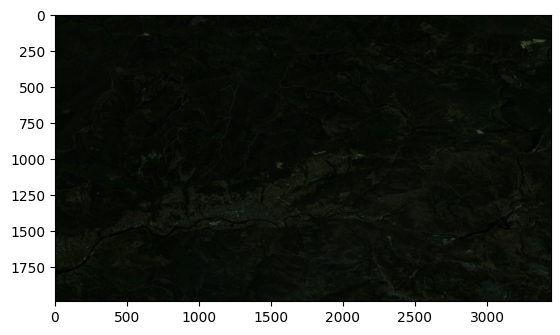

In [18]:
ds = rio.open(tifs[1])
show(ds.read((4,3,2))/4000)
plt.show()

In the next notebook we will train a Hazard model using the Sentinel 2 data and other wather variables as inputs and the hotspots as the target.